In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

#hyperparameters according to the recs
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 128
epochs = 10 #lowest suggested
learning_rate = 1e-3
latent_dim = 2

#load dataset and prepare dataloaders
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

#VAE model def
class VAE(nn.Module):
    def __init__(self, latent_dim):
        super(VAE, self).__init__()
        self.fc1 = nn.Linear(784, 400)
        self.fc_mu = nn.Linear(400, latent_dim) #for the mean vector
        self.fc_logvar = nn.Linear(400, latent_dim) #for the logvariance vector
        self.fc3 = nn.Linear(latent_dim, 400)
        self.fc4 = nn.Linear(400, 784)

    def encode(self, x): #relu activition used as recd
        h1 = F.relu(self.fc1(x))
        return self.fc_mu(h1), self.fc_logvar(h1)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h3 = F.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h3))

    def forward(self, x):
        mu, logvar = self.encode(x.view(-1, 784))
        z = self.reparameterize(mu, logvar)
        recon_x = self.decode(z)
        return recon_x, mu, logvar

def vae_loss(recon_x, x, mu, logvar):
    #loss is bce+kl divergence as recd
    BCE = F.binary_cross_entropy(recon_x, x.view(-1, 784), reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

#model and optimizer
model = VAE(latent_dim=latent_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

#training
model.train()
for epoch in range(1, epochs + 1):
    train_loss = 0
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)
        optimizer.zero_grad()
        
        recon_batch, mu, logvar = model(data)
        loss = vae_loss(recon_batch, data, mu, logvar)
        
        loss.backward()
        train_loss += loss.item()
        optimizer.step()
        
    avg_loss = train_loss / len(train_loader.dataset)
    print(f'Epoch: {epoch}/{epochs} \t Average Loss: {avg_loss:.4f}')

Epoch: 1/10 	 Average Loss: 189.5597
Epoch: 2/10 	 Average Loss: 166.7169
Epoch: 3/10 	 Average Loss: 162.5468
Epoch: 4/10 	 Average Loss: 160.1244
Epoch: 5/10 	 Average Loss: 158.4649
Epoch: 6/10 	 Average Loss: 157.2519
Epoch: 7/10 	 Average Loss: 156.3206
Epoch: 8/10 	 Average Loss: 155.5582
Epoch: 9/10 	 Average Loss: 154.8495
Epoch: 10/10 	 Average Loss: 154.2959


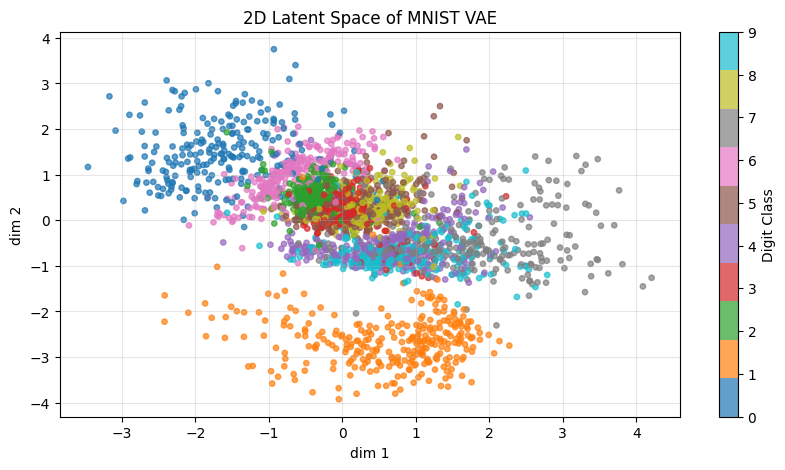

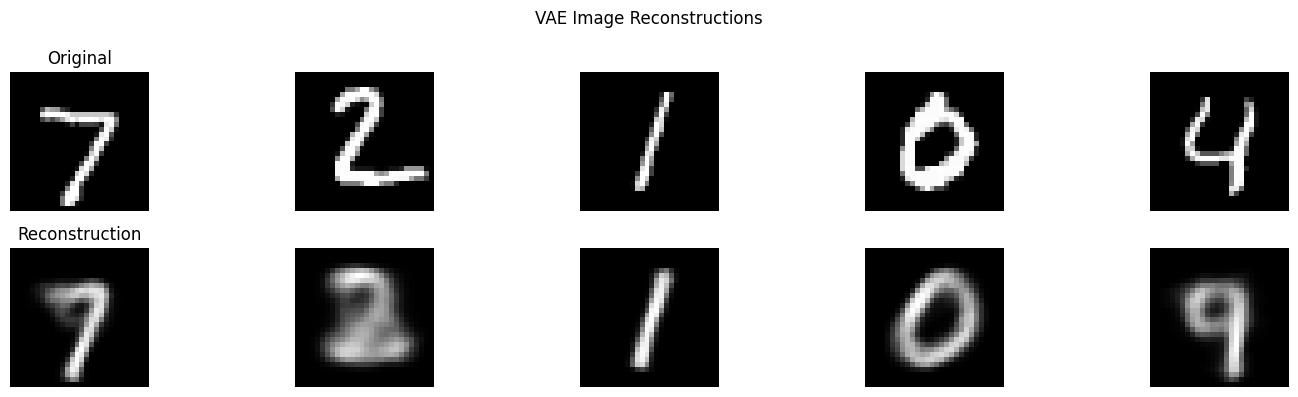

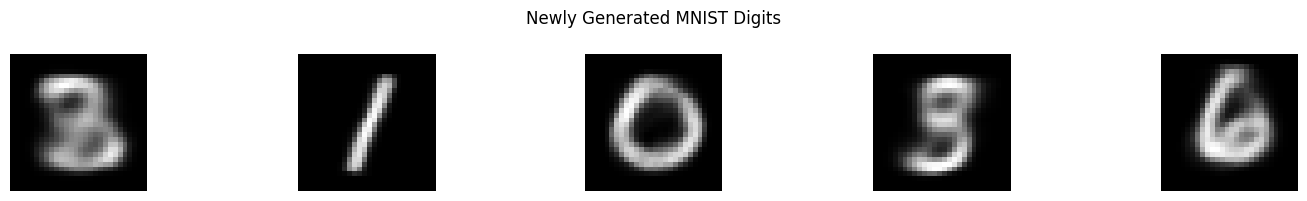

In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt

model.eval()

#latent space
all_mus = []
all_labels = []

with torch.no_grad():
    for i, (data, labels) in enumerate(test_loader):
        if i > 20:
            break
        data = data.to(device)
        mu, _ = model.encode(data.view(-1, 784))
        all_mus.append(mu.cpu().numpy())
        all_labels.append(labels.numpy())

all_mus = np.concatenate(all_mus, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

plt.figure(figsize=(10,5))
scatter = plt.scatter(all_mus[:, 0], all_mus[:, 1], c=all_labels, cmap='tab10', alpha=0.7, s=15)
plt.colorbar(scatter, ticks=range(10), label='Digit Class')
plt.title("2D Latent Space of MNIST VAE")
plt.xlabel("dim 1")
plt.ylabel("dim 2")
plt.grid(True, alpha=0.3)
plt.show()

#veryfying recontruction from 5 images in a batch
dataiter = iter(test_loader)
images, _ = next(dataiter)
images = images[:5].to(device)

with torch.no_grad():
    recon_images, _, _ = model(images)
    
recon_images = recon_images.view(-1, 1, 28, 28).cpu()
images = images.cpu()

fig, axes = plt.subplots(2, 5, figsize=(15, 4))
for i in range(5):
    axes[0, i].imshow(images[i].squeeze(), cmap='gray')
    axes[0, i].axis('off')
    if i == 0: axes[0, i].set_title("Original")
    axes[1, i].imshow(recon_images[i].squeeze(), cmap='gray')
    axes[1, i].axis('off')
    if i == 0: axes[1, i].set_title("Reconstruction")
    
plt.suptitle("VAE Image Reconstructions")
plt.tight_layout()
plt.show()

#new samples generation
random_latent_vectors = torch.randn(5, latent_dim).to(device)

with torch.no_grad():
    generated_images = model.decode(random_latent_vectors)

generated_images = generated_images.view(-1, 1, 28, 28).cpu()

fig, axes = plt.subplots(1, 5, figsize=(15, 2))
for i in range(5):
    axes[i].imshow(generated_images[i].squeeze(), cmap='gray')
    axes[i].axis('off')
    
plt.suptitle("Newly Generated MNIST Digits")
plt.tight_layout()
plt.show()